# Build a basic Chatbot with Langgraph (Graph Api)

In [24]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [25]:
class State(TypedDict):
    # Messages have the type "list". The 'add_messages' function 
    # in the annotation defines how this state key should be updated
    # (in this case, it appends to the list rather thean overwritting them)
    messages:Annotated[list, add_messages]

graph_builder=StateGraph(State)

In [26]:
graph_builder

In [27]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [28]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama3-8b-8192")

In [29]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3 8B', 'status': 'deprecated', 'release_date': '2024-04-18', 'last_updated': '2024-04-18', 'open_weights': True, 'max_input_tokens': 8192, 'max_output_tokens': 8192, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x11ba4c550>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11ba4cf50>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [30]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x11a56d220>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11a56dba0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [31]:
## Node functionality
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [32]:
graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node('llmchhatbot', chatbot)

## Adding edges
graph_builder.add_edge(START, "llmchhatbot")
graph_builder.add_edge("llmchhatbot", END)

## complete the graph
graph = graph_builder.compile()

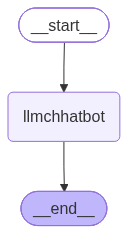

In [33]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [34]:
response = graph.invoke({'messages': 'Hi'})

In [35]:
response['messages'][-1].content

"It's nice to meet you. Is there something I can help you with, or would you like to chat?"

In [36]:
for event in graph.stream({"messages": "Hi, how are you?"}):
    for value in event.values():
        print(value['messages'][-1].content)

I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you might have. How can I assist you today?


### Chatbot with tool

In [37]:
from langchain_tavily import TavilySearch
tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph?")

{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph',
   'content': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. [...] langgraph: Framework for building graph-based AI workflows.\n langchain: Popular toolkit for LLM-powered AI applications.\n google-generativeai: Google’s API for Generative AI (Gemini models).\n\n Python  ````\n! pip install langgraph langchain google - generativeai\n```` \n\n### Step 2: Setup Gemini API',
   'score': 0.9573457,
   'raw_content': None},
  {'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangC

In [38]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): secons int
        
    Returns:
        int: output int
    """
    return a*b

tools = [tool, multiply]
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x11a56d220>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11a56dba0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimiz

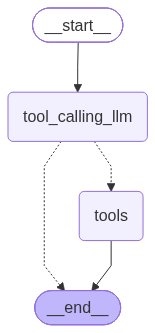

In [39]:
## Stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

## complie the graph
graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [40]:
response = graph.invoke({"messages": "What is the recent AI news?"})
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.briefs.co/news/openai-cuts-costs-for-latest-ai-models-as-enterprises-tighte", "title": "OpenAI Cuts Prices on Its Newest AI Models", "content": "Jul 31, 2026\\n\\n#### Semiconductor Shares Soar as Microsoft and Lam Earnings Counter AI Slowdown Fears\\n\\nJul 31, 2026\\n\\n#### America Strikes Dozens of Iranian Military Sites Following Jordan Attack\\n\\nJul 31, 2026\\n\\n#### Small Businesses Turn to Expensive Cash Advances Amid Tariff Pressures\\n\\nJul 31, 2026\\n\\n#### Get Market Briefs every morning for free!\\n\\nNo fluff. No noise. No politics. Just finance news in 5 minutes.\\n\\nSubscribe Free\\n\\n## Recent News\\n\\nTechnology\\n\\nJuly 31, 2026 [...] July 30, 2026\\n\\n### Yen Surges 3.3% on Intervention SuspicionsRead more\\n\\nEconomy\\n\\nJuly 30, 2026\\n\\n### U.S. Oil Refiners Post Unprecedented Gains as Global Fuel Stocks DwindleRead more\\n\\nTechn

In [41]:

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (6ynpayjw7)
 Call ID: 6ynpayjw7
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.briefs.co/news/openai-cuts-costs-for-latest-ai-models-as-enterprises-tighte", "title": "OpenAI Cuts Prices on Its Newest AI Models", "content": "Jul 31, 2026\n\n#### Semiconductor Shares Soar as Microsoft and Lam Earnings Counter AI Slowdown Fears\n\nJul 31, 2026\n\n#### America Strikes Dozens of Iranian Military Sites Following Jordan Attack\n\nJul 31, 2026\n\n#### Small Businesses Turn to Expensive Cash Advances Amid Tariff Pressures\n\nJul 31, 2026\n

In [42]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (n4mnmnaxs)
 Call ID: n4mnmnaxs
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [43]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (yksrfqx1t)
 Call ID: yksrfqx1t
  Args:
    query: recent ai news
    time_range: day
    topic: news
  multiply (rgtjr0vvn)
 Call ID: rgtjr0vvn
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.briefs.co/news/openai-cuts-costs-for-latest-ai-models-as-enterprises-tighte", "title": "OpenAI Cuts Prices on Its Newest AI Models", "content": "Jul 31, 2026\n\n#### Semiconductor Shares Soar as Microsoft and Lam Earnings Counter AI Slowdown Fears\n\nJul 31, 2026\n\n#### America Strikes Dozens of Iranian Military Sites Following Jordan Attack\n\nJul 31, 2026\n

## ReAct Agent Architecture

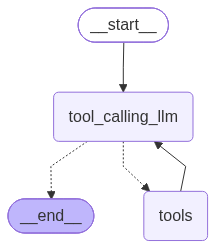

In [44]:
## Stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

## complie the graph
graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [45]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (v2mh6gcxt)
 Call ID: v2mh6gcxt
  Args:
    query: recent ai news
    search_depth: basic
    topic: news
  multiply (f6eba29gr)
 Call ID: f6eba29gr
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://sourcenm.com/2026/07/27/as-gallup-officials-respond-to-recent-flooding-they-say-an-ai-news-outlet-is-getting-in-the-way", "title": "As Gallup officials respond to recent flooding, they say an AI news outlet is getting in the way", "content": "“They’re taking things that happened years ago that are negative, bringing them to light, scaring people, and sharing f

### Adding Memory in Agentic Graph

In [46]:
response = graph.invoke({"messages": "Hello, my name is Vithlesh"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, my name is Vithlesh
================================== Ai Message ==================================

Hello Vithlesh! It's nice to meet you. Is there something I can help you with or would you like to chat?


In [47]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started, and I don't have any prior knowledge about you. If you'd like to share your name, I'd be happy to chat with you!


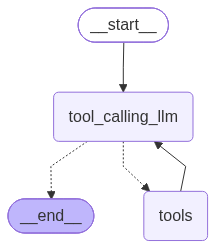

In [48]:
## Stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

## complie the graph
graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [49]:
config = {"configurable": {"thread_id":"1"}}
response = graph.invoke({"messages": "Hi, my name is Vithlesh"}, config=config)
response

{'messages': [HumanMessage(content='Hi, my name is Vithlesh', additional_kwargs={}, response_metadata={}, id='58d81a5a-dda3-4595-9ebe-5fd5ffb6fd29'),
  AIMessage(content="Hello Vithlesh, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 1754, 'total_tokens': 1782, 'completion_time': 0.067037931, 'completion_tokens_details': None, 'prompt_time': 0.090300234, 'prompt_tokens_details': None, 'queue_time': 0.050770174, 'total_time': 0.157338165}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fb9b2-445d-7462-b41e-9e505996b03b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1754, 'output_tokens': 28, 'total_tokens': 1782})]}

In [50]:
response = graph.invoke({"messages": "What is my name?"}, config=config)
response['messages'][-1].content

'Your name is Vithlesh.'

### Streaming

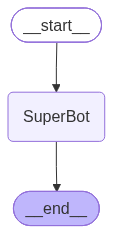

In [52]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

def superbot(state: State):
    return {"messages": [llm.invoke(state['messages'])]}

graph = StateGraph(State)

## node
graph.add_node("SuperBot", superbot)

## edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder=graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

### Streaming
Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

values : This streams the full state of the graph after each node is called.
updates : This streams updates to the state of the graph after each node is called.